# 🚗 Vehicle CO₂ Emissions Prediction using Deep Learning

## 📌 Project Overview
This project focuses on predicting **vehicle CO₂ emissions** using a **Deep Learning regression model** built with a fully connected neural network.  
The goal is to model the complex, non-linear relationships between vehicle characteristics and environmental impact.

In [1]:

# Importing the libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,classification_report,roc_auc_score,roc_curve,precision_recall_curve, confusion_matrix



In [2]:
sns.set_theme(style="whitegrid")

In [3]:
# Reading the dataset
df = pd.read_csv('co2_5.csv')
# Removing duplicates
data = df.drop_duplicates()


In [4]:
# Displaying the first few rows of the dataset
data.head()

,engine,cylandr,fuelcity,fuelwy,fuelcomb,out1
0,2.0,4,9.9,6.7,8.5,196
1,2.4,4,11.2,7.7,9.6,221
2,1.5,4,6.0,5.8,5.9,136
3,3.5,6,12.7,9.1,11.1,255
4,3.5,6,12.1,8.7,10.6,244


In [5]:
data.shape

(4360, 6)

In [6]:
# Getting information about the dataset
data.describe()

,engine,cylandr,fuelcity,fuelwy,fuelcomb,out1
count,4360.000000,4360.000000,4360.000000,4360.000000,4360.000000,4360.000000
mean,3.111124,5.544954,12.464679,9.018073,10.913188,248.982798
std,1.330996,1.814979,3.516068,2.265768,2.918367,59.555114
min,0.900000,3.000000,4.200000,4.000000,4.100000,96.000000
25%,2.000000,4.000000,9.900000,7.400000,8.800000,205.000000
50%,3.000000,6.000000,12.000000,8.700000,10.500000,244.000000
75%,3.600000,6.000000,14.400000,10.200000,12.500000,285.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,522.000000


In [7]:
# Checking for missing values and data types
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4360 entries, 0 to 7384
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   engine    4360 non-null   float64
 1   cylandr   4360 non-null   int64  
 2   fuelcity  4360 non-null   float64
 3   fuelwy    4360 non-null   float64
 4   fuelcomb  4360 non-null   float64
 5   out1      4360 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 238.4 KB


In [8]:
data.isna().sum()

engine      0
cylandr     0
fuelcity    0
fuelwy      0
fuelcomb    0
out1        0
dtype: int64

In [9]:
# Feature & Target Separation
x = data.drop(["out1"], axis=1)
y = data["out1"]

In [10]:
x

,engine,cylandr,fuelcity,fuelwy,fuelcomb
0,2.0,4,9.9,6.7,8.5
1,2.4,4,11.2,7.7,9.6
2,1.5,4,6.0,5.8,5.9
3,3.5,6,12.7,9.1,11.1
4,3.5,6,12.1,8.7,10.6
...,...,...,...,...,...
7375,2.0,4,11.3,7.5,9.6
7379,2.0,4,10.2,7.5,9.0
7380,2.0,4,10.7,7.7,9.4
7382,2.0,4,11.7,8.6,10.3


In [11]:
y

0       196
1       221
2       136
3       255
4       244
       ... 
7375    223
7379    210
7380    219
7382    240
7384    248
Name: out1, Length: 4360, dtype: int64

In [12]:
# Identify numerical columns
numerical_col=x.columns.to_list()
numerical_col

['engine', 'cylandr', 'fuelcity', 'fuelwy', 'fuelcomb']

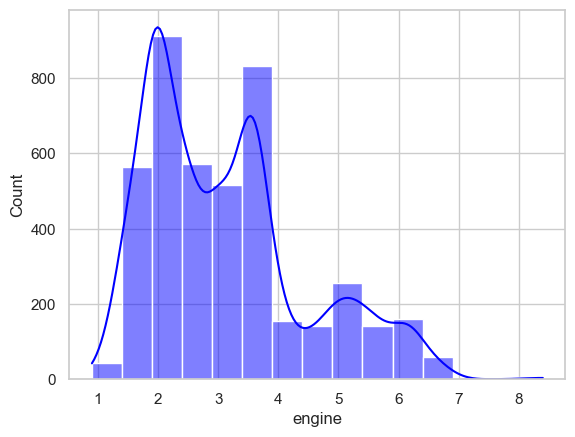

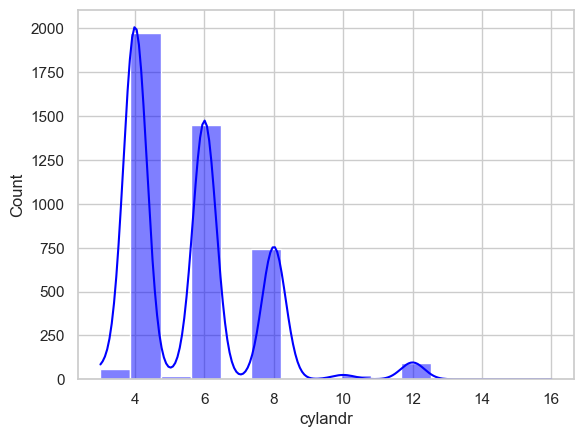

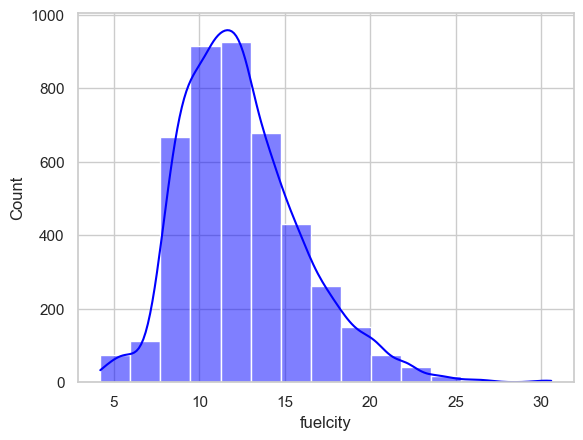

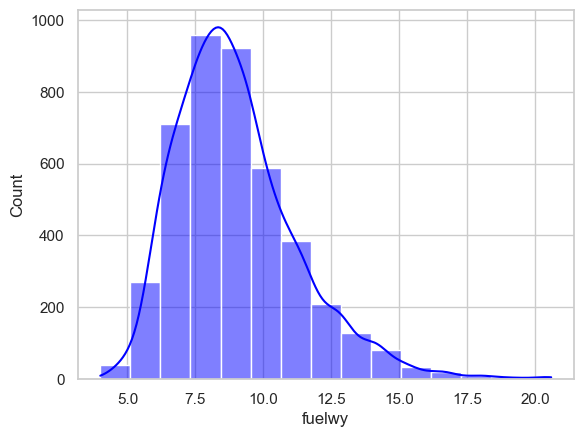

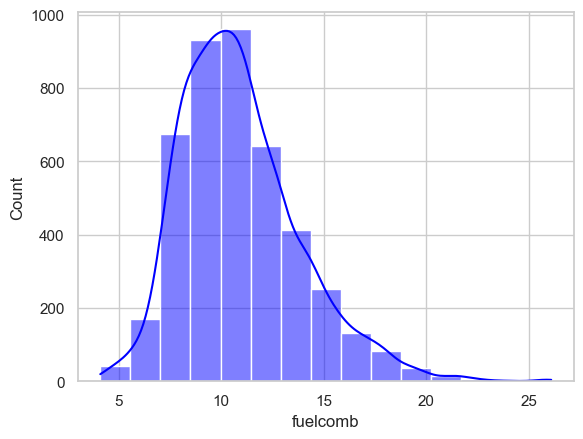

In [13]:
# Distribution of numerical features
for i in numerical_col:
   sns.histplot(data=data,x=i,bins=15,kde=True,color='blue')
   plt.show()  



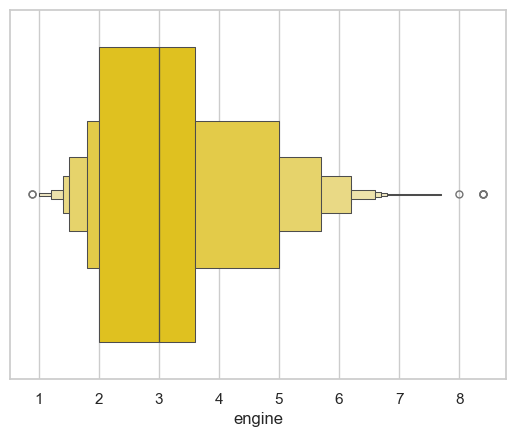

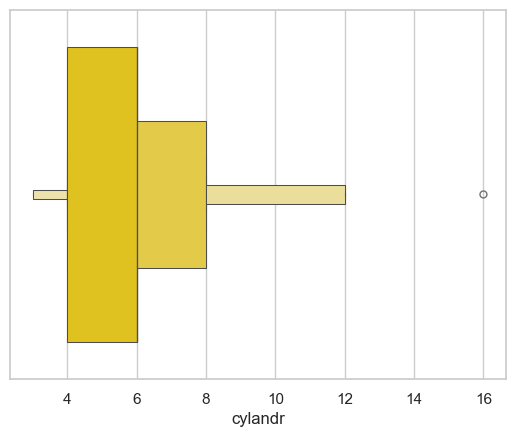

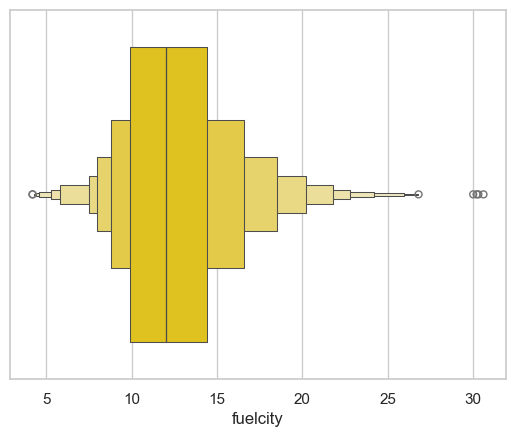

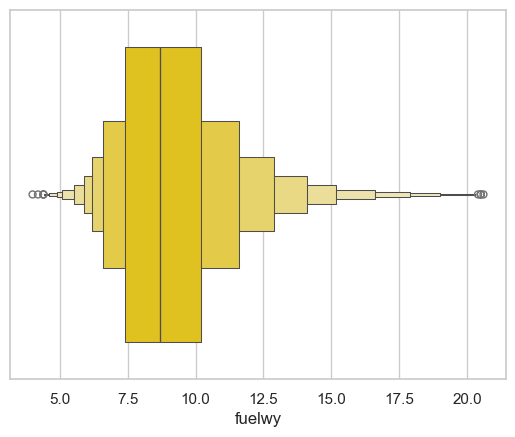

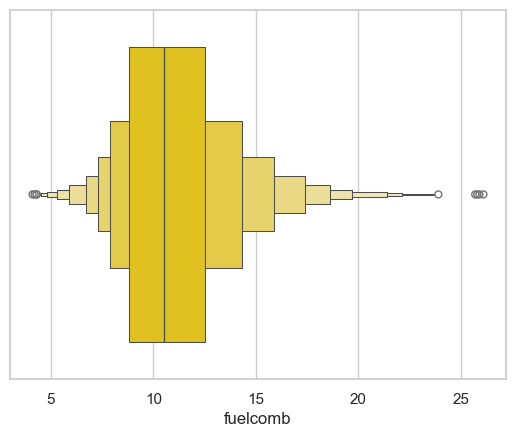

In [14]:
# out_line data we can watch
# 
for v in numerical_col:

    sns.boxenplot(data=data,x=v,color="gold")
    plt.show()

In [15]:
data['out1'].value_counts()

out1
232    49
221    48
246    47
260    47
216    45
       ..
109     1
99      1
485     1
395     1
385     1
Name: count, Length: 331, dtype: int64

<Axes: xlabel='out1', ylabel='count'>

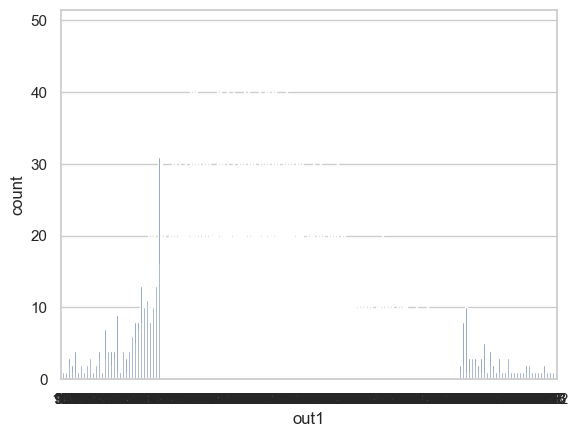

In [16]:
# count_plt
sns.countplot(x=data["out1"])

Feature Engineering and preprocessing( including of encode,scale,heatmap) after data_cleaning

In [17]:
# Feature & Target Separation
print(x.head())
print(y.head())   

   engine  cylandr  fuelcity  fuelwy  fuelcomb
0     2.0        4       9.9     6.7       8.5
1     2.4        4      11.2     7.7       9.6
2     1.5        4       6.0     5.8       5.9
3     3.5        6      12.7     9.1      11.1
4     3.5        6      12.1     8.7      10.6
0    196
1    221
2    136
3    255
4    244
Name: out1, dtype: int64


In [18]:
data['out1'].dtype

dtype('int64')

In [19]:
corr = data.corr()
corr

,engine,cylandr,fuelcity,fuelwy,fuelcomb,out1
engine,1.000000,0.926963,0.822038,0.754453,0.808305,0.844341
cylandr,0.926963,1.000000,0.790989,0.707700,0.771339,0.823752
fuelcity,0.822038,0.790989,1.000000,0.947593,0.993615,0.920868
fuelwy,0.754453,0.707700,0.947593,1.000000,0.977283,0.886540
fuelcomb,0.808305,0.771339,0.993615,0.977283,1.000000,0.920014
out1,0.844341,0.823752,0.920868,0.886540,0.920014,1.000000


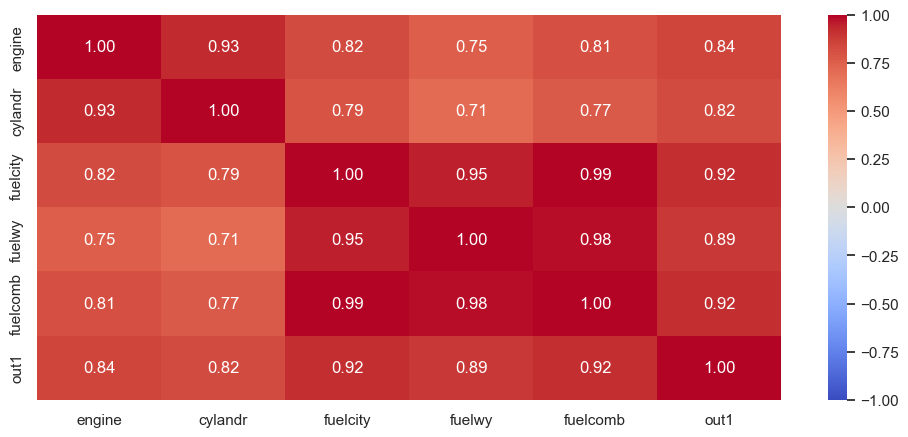

In [20]:
# Heatmap of correlation between features
plt.figure(figsize=(12,5))
sns.heatmap(data=corr,annot=True,cmap="coolwarm",vmax=1,vmin=-1,fmt='.2f')
plt.show()

In [21]:
# Train-Test Split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print(x_train.shape, y_train.shape)

(3488, 5) (3488,)


In [22]:
print(x_train)

      engine  cylandr  fuelcity  fuelwy  fuelcomb
6866     3.0        6      10.2     7.8       9.1
4810     3.6        6      13.5     9.5      11.7
3900     2.4        4      10.6     7.6       9.3
170      3.6        6      13.3     8.9      11.3
4279     2.0        4      11.3     8.3       9.9
...      ...      ...       ...     ...       ...
5319     3.6        6      14.1    10.1      12.3
665      4.6        8      15.7    11.8      13.9
4540     6.2        8      16.6    10.9      14.0
6023     2.0        4       7.7     5.9       6.9
1220     3.0        6      14.2     9.6      12.1

[3488 rows x 5 columns]


In [23]:
# scaling the data
pipline = Pipeline([('scaler', StandardScaler())])
x_train = pipline.fit_transform(x_train)
x_test = pipline.transform(x_test)

In [24]:
print(x_train)

[[-0.08321928  0.25853471 -0.64697239 -0.53912277 -0.62400855]
 [ 0.37091711  0.25853471  0.29942422  0.21647484  0.27410425]
 [-0.53735567 -0.8575161  -0.53225765 -0.62801661 -0.55492295]
 ...
 [ 2.33884146  1.37458551  1.18846346  0.8387317   1.06858864]
 [-0.84011326 -0.8575161  -1.36393952 -1.38361422 -1.38395014]
 [-0.08321928  0.25853471  0.50017502  0.26092176  0.41227545]]


In [25]:
# Now we create model 
model = Sequential()
model.add(Dense(55,input_dim = 5 , activation='relu'))
model.add(Dense(1))

model.compile(loss="mean_squared_error",optimizer='adam', metrics=['mean_squared_error'])

C:\Users\HP\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 55)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            56 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 386 (1.51 KB)

 Trainable params: 386 (1.51 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# this code is not necessary 
# this is for visualizing the model
from keras_visualizer import visualizer


visualizer(model,file_name="model_j1deep_5,1",file_format='png')

In [28]:
# Training the model
h = model.fit(x_train,y_train,epochs=50)

Epoch 1/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 64559.0312 - mean_squared_error: 64559.0312
Epoch 2/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 61810.2383 - mean_squared_error: 61810.2383
Epoch 3/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 56895.5820 - mean_squared_error: 56895.5820
Epoch 4/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 49976.0000 - mean_squared_error: 49976.0000
Epoch 5/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 41875.8633 - mean_squared_error: 41875.8633
Epoch 6/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 33859.8516 - mean_squared_error: 33859.8516
Epoch 7/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 26882.6016 - mean_squared_error: 26882.6016
Epoch 8/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 21483.9473 - mean_squared_error: 21483.9473
Epoch 9/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17733.1328 - mean_squared_error: 17733.1328
Epoch 10/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 153

In [29]:
scores = model.evaluate(x_train, y_train)
print("Training Accuracy: %.2f%%\n" % (scores[1]*100))
scores = model.evaluate(x_test, y_test)
print("Testing Accuracy: %.2f%%\n" % (scores[1]*100))

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 345.2908 - mean_squared_error: 345.2908
Training Accuracy: 34529.08%

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 325.7324 - mean_squared_error: 325.7324
Testing Accuracy: 32573.24%



In [30]:
# Making Predictions
y_pred = model.predict(x_test)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [31]:
print(y_pred)

[[193.22229 ]
 [196.67131 ]
 [171.52824 ]
 [316.1974  ]
 [302.09396 ]
 [230.5496  ]
 [353.28174 ]
 [263.05634 ]
 [298.19174 ]
 [288.2905  ]
 [257.97504 ]
 [247.71953 ]
 [265.2156  ]
 [138.94849 ]
 [337.6778  ]
 [317.51532 ]
 [244.65118 ]
 [269.21082 ]
 [157.02179 ]
 [229.40314 ]
 [119.110985]
 [292.80936 ]
 [171.10477 ]
 [195.66884 ]
 [225.57864 ]
 [215.45256 ]
 [344.9661  ]
 [412.53275 ]
 [186.57492 ]
 [243.20264 ]
 [308.81445 ]
 [193.85701 ]
 [286.1574  ]
 [156.88821 ]
 [157.32207 ]
 [323.21494 ]
 [209.48663 ]
 [259.9762  ]
 [374.69498 ]
 [241.77124 ]
 [232.39583 ]
 [263.70868 ]
 [220.3649  ]
 [170.34833 ]
 [262.36295 ]
 [355.87424 ]
 [167.65211 ]
 [223.10872 ]
 [324.423   ]
 [258.9889  ]
 [166.15178 ]
 [196.38893 ]
 [317.968   ]
 [202.51604 ]
 [333.61026 ]
 [260.31567 ]
 [252.46812 ]
 [217.85219 ]
 [258.3564  ]
 [288.81488 ]
 [257.58194 ]
 [209.72482 ]
 [228.70853 ]
 [310.76562 ]
 [275.67273 ]
 [227.16953 ]
 [231.79588 ]
 [238.45685 ]
 [227.85538 ]
 [248.69972 ]
 [262.1097  ]
 [307.

In [32]:
print(y_test)

251     191
2140    196
5398    171
2345    343
3584    248
       ... 
1113    344
3455    196
6682    296
948     221
2837    227
Name: out1, Length: 872, dtype: int64


In [33]:
test1 = np.array([[3.5,6,12.7,9.1,11.1]])

out1 = model.predict(test1)
print(out1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
[[890.57996]]


In [34]:
# get the training history
history = h.history['loss']
print(history)

[64559.03125, 61810.23828125, 56895.58203125, 49976.0, 41875.86328125, 33859.8515625, 26882.6015625, 21483.947265625, 17733.1328125, 15360.6181640625, 13888.0859375, 12890.7822265625, 12079.97265625, 11302.1689453125, 10485.1181640625, 9621.310546875, 8717.689453125, 7780.408203125, 6826.62255859375, 5882.05859375, 4968.919921875, 4115.4443359375, 3350.8798828125, 2690.98828125, 2138.41259765625, 1684.50634765625, 1329.8043212890625, 1055.96484375, 842.593505859375, 685.4318237304688, 576.3187866210938, 500.3514404296875, 452.1780090332031, 421.9006652832031, 402.1029968261719, 388.30865478515625, 378.75152587890625, 371.5823974609375, 366.77667236328125, 362.9725341796875, 360.7792053222656, 358.12542724609375, 355.87677001953125, 354.4563903808594, 353.1212158203125, 351.5885925292969, 349.8603210449219, 349.33148193359375, 347.68975830078125, 345.9311218261719]


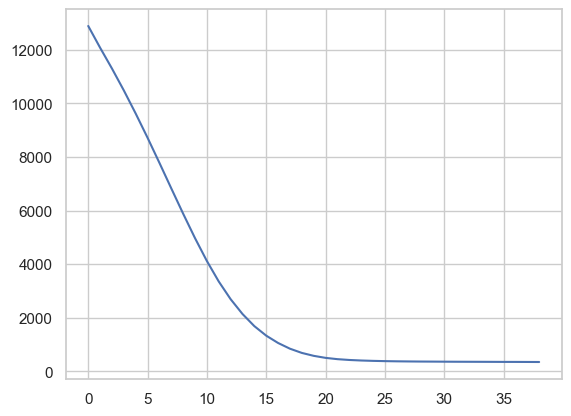

In [37]:
# Plotting the training loss over epochs
er = h.history['loss']
er = er[11:]
plt.close()
plt.plot(er)
plt.show()

In [36]:
## 👤 Author
# **Mohamad Nahvi**  
# Aspiring Data Scientist | Machine Learning & Deep Learning Enthusiast